# MAIA Surface Monitor Exploritory Tutorial

The following tutorial guides users to login using earthaccess to NASA Earthdata Search. Users then input a time frame of interest. The tutorial is split into two sections; One looking at time series of total PM 10 for available senors, another breaking down speciated PM2.5.

Mission Point of Contact/Tutorial Author
- Sarah Scott: sarah.r.scott@nasa.gov

ASDC Project Scientist
- Hazem Mahmoud: hazem.mahmoud@nasa.gov

In [1]:
!pip install harmony-py contextily pyrsig earthaccess netCDF4


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\srscott4\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [2]:
# installation and package imports
from pathlib import Path
from harmony import Client, Collection, Environment, Request
import getpass
import earthaccess
import datetime as dt
from cmr import VariableQuery
import math
import folium
from branca.colormap import linear
import os
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from geopy.geocoders import Nominatim
import time
from datetime import datetime
import matplotlib.dates as mdates
import geopandas as gpd
import xarray as xr
import glob
import platform
from subprocess import Popen

### Establishing access to EarthData
User needs to create an account at https://www.earthdata.nasa.gov/

In [3]:
#Function earthaccess.login prompts for EarthData login and password.
auth = earthaccess.login(strategy="interactive", persist=True)

### Input period of interest and MAIA Primary Target Area (PTA) of interest

In [4]:
#timeframe of interest for all datasets
print('enter period of interest, start and end dates, in the form YYYYMMDD')
datestamp_ini = input('enter start date of interest ')
datestamp_fin = input('enter end date of interest ')
start_date = int(datestamp_ini)
end_date = int(datestamp_fin)
yyyy_ini = start_date//10000
mm_ini = (start_date//100 - yyyy_ini*100)
dd_ini = (start_date - yyyy_ini*10000 - mm_ini*100)
yyyy_fin = end_date//10000
mm_fin = (end_date//100 - yyyy_fin*100)
dd_fin = (end_date - yyyy_fin*10000 - mm_fin*100)
print(yyyy_ini, mm_ini, dd_ini, yyyy_fin, mm_fin, dd_fin)
date_start = str('%4.4i-%2.2i-%2.2i 00:00:00' %(yyyy_ini, mm_ini, dd_ini))
date_end = str('%4.4i-%2.2i-%2.2i 23:59:59' %(yyyy_fin, mm_fin, dd_fin))

enter period of interest, start and end dates, in the form YYYYMMDD
2025 4 14 2025 5 1


In [5]:
#site selection
maia_ptas = ['CHL-Santiago', 'ESP-Barcelona', 'ETH-AddisAbaba', 'IND-Delhi', 'ISR-TelAviv','ITA-Rome', 'KOR-Seoul', 'TWN-Taipei', 'USA-Atlanta', 'USA-Boston', 'USA-LosAngeles', 'ZAF-Johannesburg']
for number, pta in enumerate(maia_ptas, start=1):
    print(f"{number}. {pta}")
selection = int(input("\nEnter PTA number: "))

if not 1 <= selection <= len(maia_ptas):
    raise ValueError("Invalid PTA selection.")

site = maia_ptas[selection - 1]
print(f"Selected PTA: {site}")

1. CHL-Santiago
2. ESP-Barcelona
3. ETH-AddisAbaba
4. IND-Delhi
5. ISR-TelAviv
6. ITA-Rome
7. KOR-Seoul
8. TWN-Taipei
9. USA-Atlanta
10. USA-Boston
11. USA-LosAngeles
12. ZAF-Johannesburg
Selected PTA: USA-Atlanta


### Total PM data download and visualize

In [6]:
earthaccess.login()
concept_id="C3880763244-LARC_CLOUD"
granules = earthaccess.search_data(concept_id=concept_id,temporal=(f"{yyyy_ini}-{mm_ini}-{dd_ini}", f"{yyyy_fin}-{mm_fin}-{dd_fin}"))
print(f"Found {len(granules)} granules")
granule_ids = [g["umm"]["RelatedUrls"][0]['URL'] for g in granules]
site_ids = []

for g in granule_ids:
    if g.split('/')[-1].split('_')[5] == site:
        site_ids.append(g)

total_pm_directory = os.path.join("MAIA_SURFACEMONITOR_PM_TOTAL", site)

os.makedirs(total_pm_directory, exist_ok=True)
download_files = earthaccess.download(site_ids,local_path=total_pm_directory)

Found 398 granules


QUEUEING TASKS | :   0%|          | 0/38 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/38 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/38 [00:00<?, ?it/s]

In [17]:
pm_total_type = input('enter PM10 or PM2.5 for total particulate matter of interest ')

if pm_total_type == "PM10":
    pm_group = "PM_10/Total"
    monitor_group = "PM_10/Total/Monitor_Information"
    pm_string="PM₁₀"
else:
    pm_group = "PM_2.5/Total"
    monitor_group = "PM_2.5/Total/Monitor_Information"
    pm_string="PM₂.₅"

In [15]:
dataframes = []
for nc_file in sorted(os.listdir(total_pm_directory)):
    if not nc_file.lower().endswith(".nc"):
        continue
 
    file_path = os.path.join(total_pm_directory,nc_file)

    try:
        with xr.open_dataset(file_path,group=pm_group,engine="netcdf4") as pm_ds:
            pm = pm_ds["pm_mass_concentration"].load()
            date = pm_ds["date_LST"].load()

        with xr.open_dataset(file_path,group=monitor_group,engine="netcdf4") as monitor_ds:
            latitude = monitor_ds["latitude"].load()
            longitude = monitor_ds["longitude"].load()
            station_name = monitor_ds["site_name"].load()

    except (OSError, ValueError, KeyError) as error:
        print(f"Skipping {nc_file}: {error}")
        continue

    pm_values = pm.values.reshape(-1)
    latitude_values = latitude.values.reshape(-1)
    longitude_values = longitude.values.reshape(-1)
    date_values = date.values.reshape(-1)
    station_values = station_name.values.reshape(-1)

    if not (len(pm_values)== len(latitude_values)== len(longitude_values)):
        raise ValueError(
            f"Variable lengths do not match in {nc_file}: "
            f"PM={len(pm_values)}, "
            f"latitude={len(latitude_values)}, "
            f"longitude={len(longitude_values)}")

    if len(date_values) == 1:
        date_values = np.repeat(date_values, len(pm_values))

    elif len(date_values) != len(pm_values):
        raise ValueError(
            f"Date length does not match PM length "
            f"in {nc_file}: "
            f"date={len(date_values)}, "
            f"PM={len(pm_values)}")

    file_df = pd.DataFrame({ "pm_mass_concentration": pm_values, "latitude": latitude_values, "longitude": longitude_values, "date": date_values,"station_name": station_values, "source_file": nc_file,})
    dataframes.append(file_df)

if not dataframes:
    raise RuntimeError("No valid NetCDF files were processed.")

df = pd.concat(dataframes,ignore_index=True)
df["date"] = pd.to_datetime(df["date"].astype(str).str.replace("b'", "",regex=False).str.replace( "'", "", regex=False),format="%Y%m%d",errors="coerce")
df = df.dropna( subset=["pm_mass_concentration", "latitude", "longitude" ]).reset_index(drop=True)

In [16]:
plot_df = df.dropna(subset=["pm_mass_concentration","latitude","longitude"]).copy()
print('enter date of interest, start and end dates, in the form YYYYMMDD')
user_date = input('enter start date of interest ')
selected_date = pd.Timestamp(user_date).date()
plot_df = plot_df[plot_df["date"].dt.date== pd.Timestamp(selected_date).date()]
center_latitude = plot_df["latitude"].mean()
center_longitude = plot_df["longitude"].mean()
pm_map = folium.Map( location=[center_latitude, center_longitude],zoom_start=9,tiles="CartoDB positron")
minimum_pm = plot_df["pm_mass_concentration"].min()
maximum_pm = plot_df["pm_mass_concentration"].max()

if minimum_pm == maximum_pm:
    maximum_pm = minimum_pm + 1

color_scale = linear.YlOrRd_09.scale(minimum_pm,maximum_pm)
color_scale.caption = ("PM₁₀ mass concentration (µg/m³)")
color_scale.add_to(pm_map)

for _, row in plot_df.iterrows():
    pm_value = row["pm_mass_concentration"]
    latitude = row["latitude"]
    longitude = row["longitude"]
    popup_text = (
        f"<b>PM₁₀:</b> {pm_value:.2f} µg/m³<br>"
        f"<b>Latitude:</b> {latitude:.5f}<br>"
        f"<b>Longitude:</b> {longitude:.5f}")

    if "date" in plot_df.columns:
        popup_text += (
            f"<br><b>Date:</b> "
            f"{pd.to_datetime(row['date']).date()}")

    folium.CircleMarker(location=[latitude, longitude],radius=7,color="black",weight=1,fill=True,fill_color=color_scale(pm_value),fill_opacity=0.85,tooltip=f"PM₁₀: {pm_value:.2f} µg/m³",
        popup=folium.Popup(popup_text,max_width=300)).add_to(pm_map)

pm_map.fit_bounds([[plot_df["latitude"].min(),plot_df["longitude"].min()], [ plot_df["latitude"].max(), plot_df["longitude"].max()]])
pm_map

enter date of interest, start and end dates, in the form YYYYMMDD


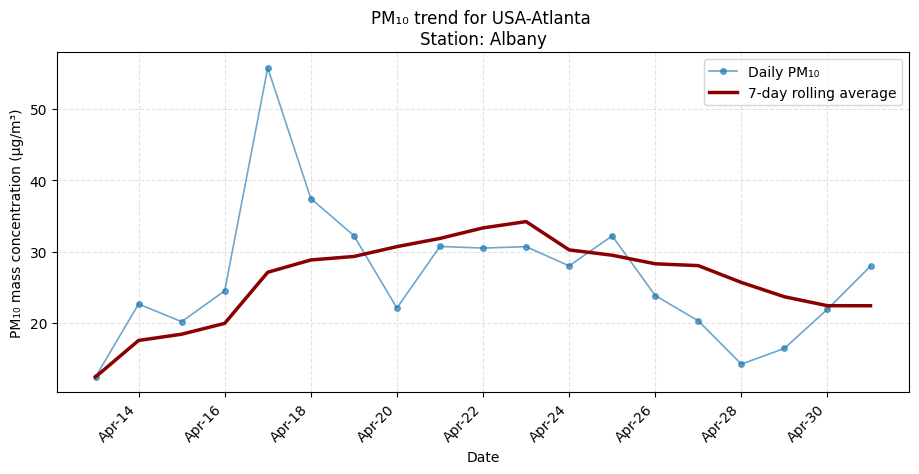

In [ ]:
plot_df = df.copy()
plot_df["date"] = pd.to_datetime(plot_df["date"],errors="coerce")
plot_df["pm_mass_concentration"] = pd.to_numeric(plot_df["pm_mass_concentration"],errors="coerce")
plot_df = plot_df.dropna(subset=[ "date", "pm_mass_concentration","latitude","longitude",])
plot_df["latitude"] = plot_df["latitude"].round(5)
plot_df["longitude"] = plot_df["longitude"].round(5)
daily_df = (plot_df.groupby(["station_name", "latitude", "longitude", "date"], as_index=False)["pm_mass_concentration"].mean().sort_values(["station_name","latitude", "longitude", "date"]))
output_directory = Path("PM10_timeseries_by_location")
output_directory.mkdir(parents=True,exist_ok=True)
location_count = 0

for (station_name, latitude, longitude), location_df in daily_df.groupby(["station_name", "latitude", "longitude"]):
    location_count += 1
    location_df = location_df.sort_values("date").copy()

    #7-day rolling average to show the broader trend
    location_df["rolling_7day"] = (location_df["pm_mass_concentration"].rolling(window=7,min_periods=1).mean())
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(location_df["date"],location_df["pm_mass_concentration"],marker="o",markersize=4,linewidth=1.2,alpha=0.65,label="Daily {pm_string}")
    ax.plot(location_df["date"],location_df["rolling_7day"],linewidth=2.5,color="darkred",label="7-day rolling average")
    ax.set_title(f"{pm_string} trend for {site} \nStation: {station_name}")
    ax.set_xlabel("Date")
    ax.set_ylabel(f"{pm_string} mass concentration (µg/m³)")
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
    ax.grid(True,linestyle="--",alpha=0.35)
    ax.legend()
    fig.autofmt_xdate(rotation=45)

    
    # fig.tight_layout()
    # output_file = output_directory / (
    #     f"PM10_lat_{latitude:.5f}_"
    #     f"lon_{longitude:.5f}.png")

    # fig.savefig(output_file,dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    break

### Speciated PM2.5 download and visualize

In [6]:
concept_id="C3880763231-LARC_CLOUD"
granules = earthaccess.search_data(concept_id=concept_id,temporal=(f"{yyyy_ini}-{mm_ini}-{dd_ini}", f"{yyyy_fin}-{mm_fin}-{dd_fin}"))
print(f"Found {len(granules)} granules")
granule_ids = [g["umm"]["RelatedUrls"][0]['URL'] for g in granules]
site_ids = []

for g in granule_ids:
    if g.split('/')[-1].split('_')[6] == site:
        site_ids.append(g)

speciated_pm_directory = os.path.join("MAIA_SURFACEMONITOR_PM_2.5_SPECIES", site)

os.makedirs(speciated_pm_directory, exist_ok=True)
download_files = earthaccess.download(site_ids,local_path=speciated_pm_directory)

Found 94 granules


QUEUEING TASKS | :   0%|          | 0/7 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/7 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/7 [00:00<?, ?it/s]

In [7]:
import numpy as np
import pandas as pd
from netCDF4 import Dataset

def nc_to_tidy_dataframe(file_path):
    nc = Dataset(file_path, 'r')
    pm25 = nc.groups["PM_2.5"]
    records = []

    for species_name, species_group in pm25.groups.items():
        conc_var = species_group.variables.get('pm_mass_concentration')            
        conc_vals = conc_var[:]
        if hasattr(conc_var, '_FillValue'):
            conc_vals = np.ma.masked_equal(conc_vals, conc_var._FillValue)
        conc_vals = np.ma.filled(conc_vals, np.nan)

        mon_info = species_group.groups.get('Monitor_Information')
        lats = mon_info.variables['latitude'][:] if 'latitude' in mon_info.variables else [np.nan] * len(conc_vals)
        lons = mon_info.variables['longitude'][:] if 'longitude' in mon_info.variables else [np.nan] * len(conc_vals)
        
        site_names = []
        if 'site_name' in mon_info.variables:
            raw_sites = mon_info.variables['site_name'][:]
            site_names = [s.decode('utf-8', errors='ignore').strip() if isinstance(s, (bytes, np.bytes_)) else str(s).strip() for s in raw_sites]
        else:
            site_names = [None] * len(conc_vals)

        date_key = next((k for k in species_group.variables.keys() if 'date' in k or 'time' in k), None)
        dates = species_group.variables[date_key][:] if date_key else [np.nan] * len(conc_vals)
        dates = [d.decode('utf-8', errors='ignore').strip() if isinstance(d, (bytes, np.bytes_)) else str(d) for d in dates]

        for i in range(len(conc_vals)):
            lat_val = lats[i] if -90 <= lats[i] <= 90 else np.nan
            lon_val = lons[i] if -180 <= lons[i] <= 180 else np.nan
            records.append({'date': dates[i],'site_name': site_names[i],'latitude': lat_val,'longitude': lon_val,'species': species_name,'pm_mass_concentration': conc_vals[i]})

    nc.close()
    df = pd.DataFrame(records)
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['pm_mass_concentration']).reset_index(drop=True)    
    return df
file_paths = glob.glob(f'{speciated_pm_directory}/*.nc') #for speciated pm only 
dfs = []
for f in file_paths:
    single_df = nc_to_tidy_dataframe(f)
    single_df['file_source'] = f
    dfs.append(single_df)

master_df = pd.concat(dfs, ignore_index=True)

3 3


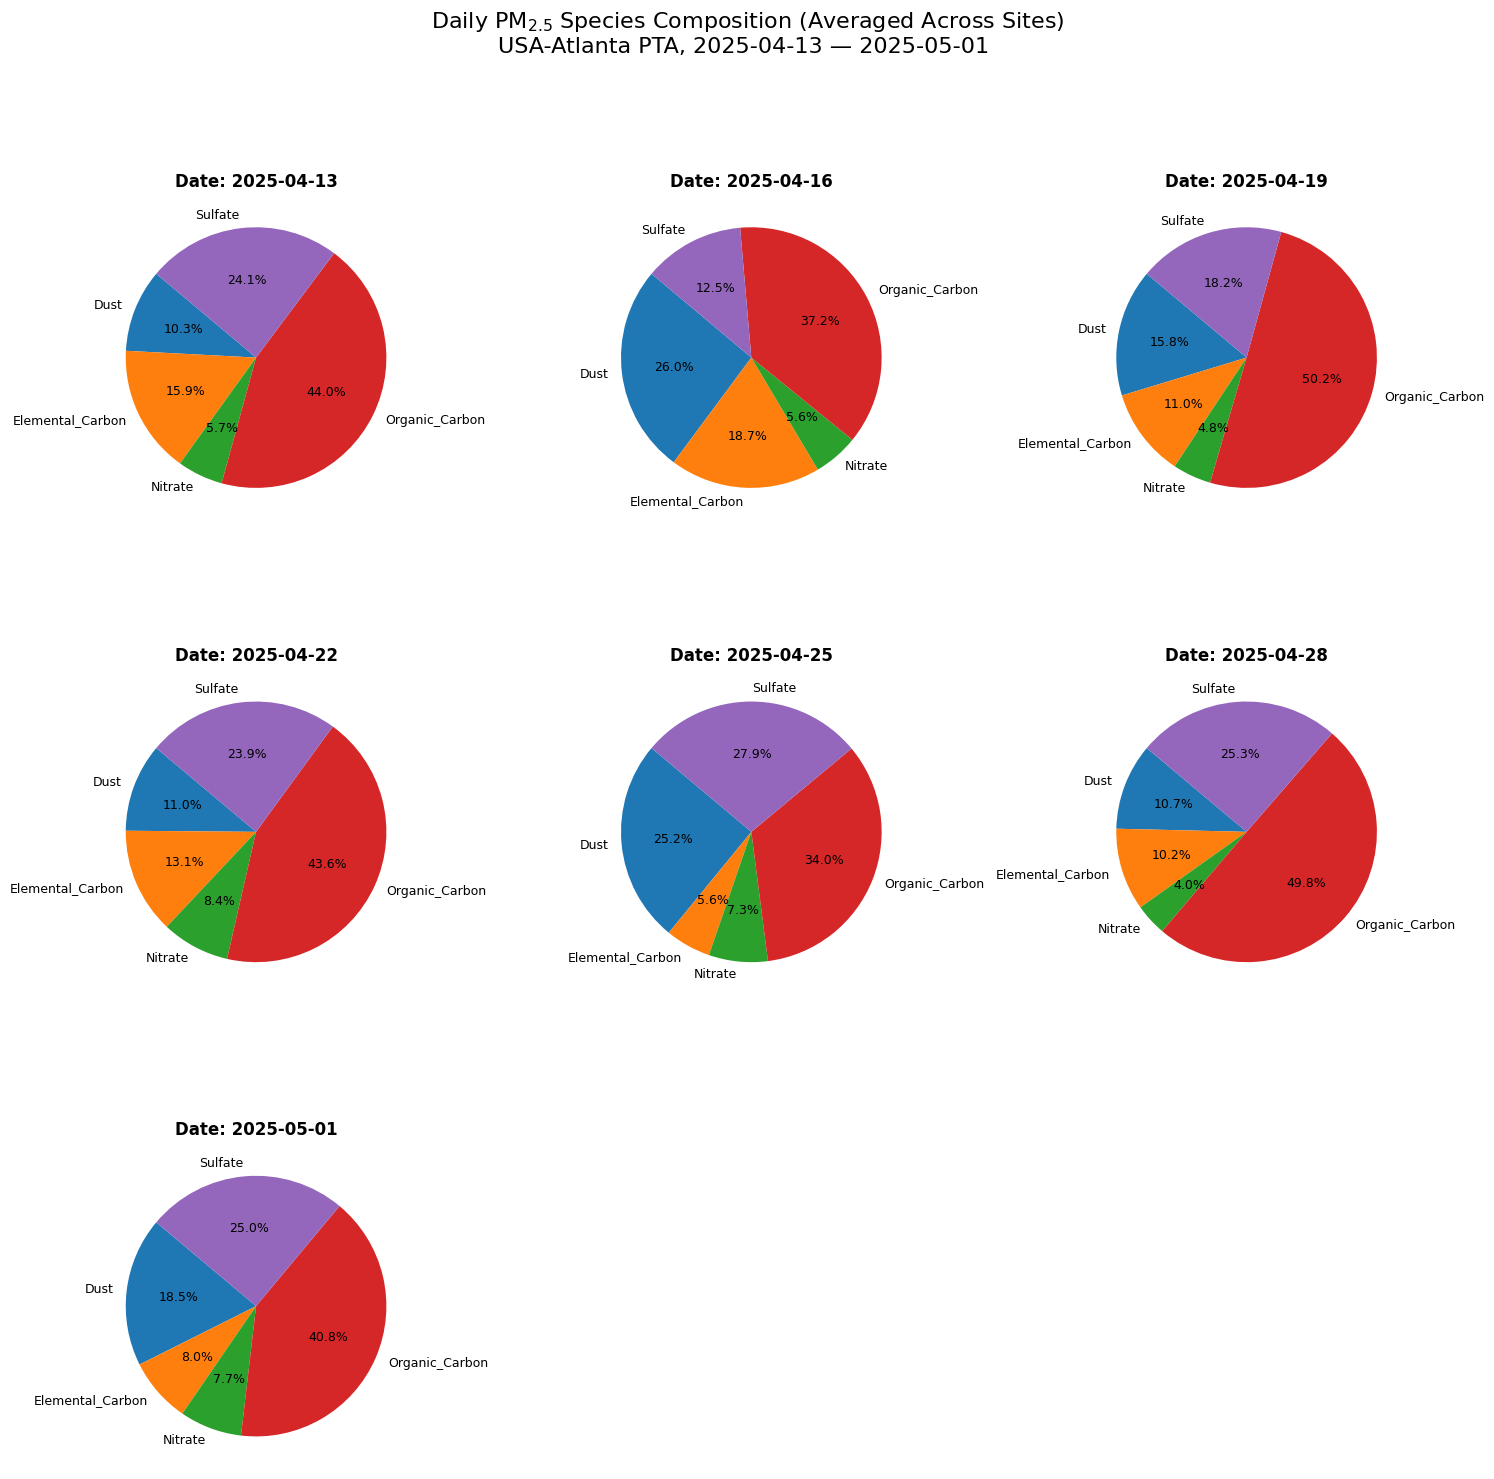

In [8]:
daily_avg = (master_df.groupby(['date', 'species'])['pm_mass_concentration'].mean().reset_index())
daily_avg = daily_avg[daily_avg['pm_mass_concentration'] > 0].dropna(subset=['pm_mass_concentration'])
valid_days = daily_avg.groupby('date')['pm_mass_concentration'].sum()
valid_days = valid_days[valid_days > 0].index
daily_avg = daily_avg[daily_avg['date'].isin(valid_days)]
unique_dates = daily_avg['date'].dt.strftime('%Y-%m-%d').unique()

num_days = len(unique_dates)
cols = min(3, num_days)  # Max 3 columns
rows = math.ceil(num_days / cols)

print(cols, rows)
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = np.array(axes).reshape(-1)  
unique_species = daily_avg['species'].unique()
color_map = dict(zip(unique_species, plt.cm.tab10.colors[:len(unique_species)]))

for i, date_str in enumerate(unique_dates):
    day_data = daily_avg[daily_avg['date'].dt.strftime('%Y-%m-%d') == date_str]
    slices = day_data['pm_mass_concentration'].values
    labels = day_data['species'].values
    total_mass = np.nan_to_num(slices).sum()
    
    if total_mass > 0:
        colors = [color_map[s] for s in labels]
        
        axes[i].pie(
            slices, 
            labels=labels, 
            colors=colors, 
            autopct='%1.1f%%', 
            startangle=140,
            textprops={'fontsize': 9}
        )
        axes[i].set_xticks([])
        axes[i].set_yticks([])

    axes[i].set_title(f"Date: {date_str}", fontsize=12, fontweight='bold')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f"Daily PM$_{{2.5}}$ Species Composition (Averaged Across Sites)\n{site} PTA, {unique_dates[0]} — {unique_dates[-1]} ", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()